# 2D случай

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
class Robot:
    def __init__(
            self,
            link_lengths=[50, 40, 30, 30],
            theta_array=[np.pi/2, 0, 0, 0]
        ):
        self.links = np.asarray(link_lengths)
        self.set_pose(theta_array)
        
    def forward_kinematics(self, theta_array, change_robot_conf=False) -> np.ndarray:
        if change_robot_conf:
            self.set_pose(theta_array)
        f_fk = np.zeros((self.links.size, 2))
        phi = 0
        J_m = np.zeros(2)
        for i in range(self.links.size):
            phi += theta_array[i]
            J_m += self.links[i] * np.array([np.cos(phi), np.sin(phi)])
            f_fk[i] = J_m
        return f_fk

    def column_jacobi(self, joint_num, col_num) -> np.array:
        total_sum = np.zeros(2)
        phi = np.sum(self._Thetas[:col_num])
        for i in range(col_num, joint_num+1):
            phi += self._Thetas[i]
            total_sum += self.links[i] * np.array([-np.sin(phi), np.cos(phi)])
        return total_sum
    
    def jacobi(self, joint_num) -> np.ndarray:
        jacobi_matrix = np.zeros((2, self.links.size))
        for i in range(self.links.size):
            jacobi_matrix[:, i] = self.column_jacobi(joint_num, i)
        return jacobi_matrix

    def set_pose(self, theta_array) -> None:
        self._Thetas = np.asarray(theta_array)
        assert self.links.size == self._Thetas.size, "Size of theta_array must be equal to link_lengths's size!"
    
    def get_pose(self) -> np.array:
        return self._Thetas

In [3]:
def loss_and_grad(robot, theta, target_indices, target_points):
    joints = robot.forward_kinematics(theta, change_robot_conf=True)

    loss = 0.0
    grad = np.zeros_like(theta, dtype=float)

    for joint_idx, target in zip(target_indices, target_points):
        residual = joints[joint_idx] - target
        Jacobi = robot.jacobi(joint_idx)

        loss += residual.T @ residual
        grad += 2 * Jacobi.T @ residual

    return loss, grad

def solve_regression(
    robot,
    target_indices,
    target_points,
    theta_init=None,
    lr=1e-5,
    max_iter=10000,
    tol=1e-6,
):
    if theta_init is None:
        theta = robot.get_pose().copy()
    else:
        theta = np.asarray(theta_init, dtype=float).copy()

    history = []

    for step in range(max_iter):
        loss, grad = loss_and_grad(robot, theta, target_indices, target_points)
        history.append(loss)

        if np.linalg.norm(grad) < tol:
            break

        theta -= lr * grad
        theta = (theta + np.pi) % (2 * np.pi) - np.pi

    robot.set_pose(theta)
    return theta, history

In [4]:
def robot_points(robot, theta):
    joints = robot.forward_kinematics(theta, change_robot_conf=False)
    return np.vstack([np.zeros(2), joints])


def plot_robot_solution(
    robot,
    theta_start,
    theta_final,
    target_indices,
    target_points,
    filename="robot_solution.png"
):
    theta_start = np.asarray(theta_start, dtype=float)
    theta_final = np.asarray(theta_final, dtype=float)
    target_indices = np.asarray(target_indices, dtype=int)
    target_points = np.asarray(target_points, dtype=float)

    start_points = robot_points(robot, theta_start)
    final_points = robot_points(robot, theta_final)

    fig, ax = plt.subplots()

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linewidth=0.3)

    all_points = np.vstack([start_points, final_points, target_points])
    margin = max(10.0, 0.1 * np.sum(robot.links))

    ax.set_xlim(all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
    ax.set_ylim(all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)

    ax.plot(
        start_points[:, 0],
        start_points[:, 1],
        linestyle="--",
        color="#dc2626",
        linewidth=3,
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="#dc2626",
        markeredgewidth=2,
        label="initial pose",
        zorder=3,
    )

    ax.plot(
        final_points[:, 0],
        final_points[:, 1],
        linestyle="-",
        color="#2563eb",
        linewidth=4,
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="#111827",
        markeredgewidth=2,
        label="final pose",
        zorder=4,
    )

    ax.scatter(
        target_points[:, 0],
        target_points[:, 1],
        marker="x",
        s=130,
        linewidths=3,
        color="#7c3aed",
        label="targets",
        zorder=5,
    )

    for joint_idx, target in zip(target_indices, target_points):
        ax.text(
            target[0],
            target[1],
            f"  G{joint_idx + 1}",
            color="#7c3aed",
            fontsize=11,
            weight="bold",
        )

    ax.set_title("Manipulator solution")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


def plot_loss(loss_history, filename="loss.png"):
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(loss_history, color="#16a34a", linewidth=1.5)

    ax.set_title("Loss")
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")

    ax.grid(True, linewidth=0.5)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

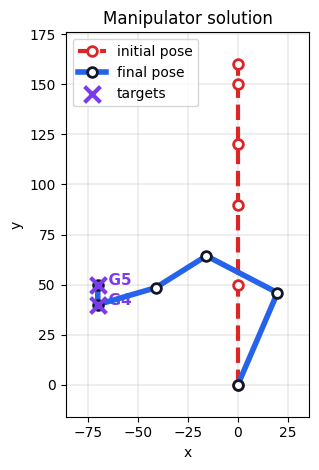

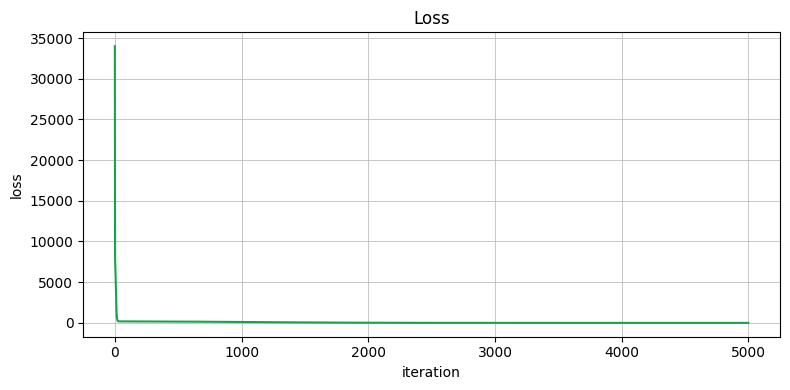

In [5]:
robot = Robot(
    link_lengths=[50, 40, 30, 30, 10],
    theta_array=[np.pi / 2, 0, 0, 0, 0],
)

theta_start = robot.get_pose().copy()

target_indices = [3, 4]
target_points = np.array([
    [-70, 40],
    [-70, 50]
])

theta_final, loss_history = solve_regression(
    robot,
    target_indices,
    target_points,
    theta_init=theta_start,
    lr=1e-5,
    max_iter=5000
)

plot_robot_solution(
    robot,
    theta_start,
    theta_final,
    target_indices,
    target_points,
    "python_data/robot_solution1.png"
)

plot_loss(loss_history, "python_data/loss1.png")